In [17]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.utils import gen_batches
from datasets import load_dataset

In [18]:
### download data
dataset = load_dataset("mnist")

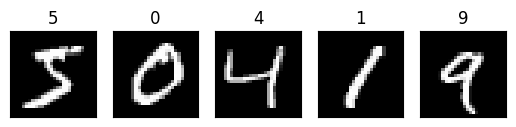

In [19]:
### reformat into pandas and show example with label

def plot_example(X, y):
    """Plot the first 5 images and their labels in a row."""
    for i, (img, y) in enumerate(zip(X[:5].reshape(5, 28, 28), y[:5])):
        plt.subplot(151 + i)
        plt.imshow(img, cmap='gray')
        plt.xticks([])
        plt.yticks([])
        plt.title(y)
        
train_data = dataset['train'].with_format("numpy")
test_data = dataset['test'].with_format("numpy")

X_train = train_data['image'].reshape(len(train_data), 784)
y_train = train_data['label']

X_test = test_data['image'].reshape(len(test_data), 784)
y_test = test_data['label']

plot_example(X_train, y_train)

In [20]:
### normalize and binarize

X_train = X_train / 255
X_train = np.where(X_train > 0.5, 1, 0)
X_test = X_test / 255
X_test = np.where(X_test > 0.5, 1, 0)

In [21]:
# ### MODEL

# class RBM():

#     def __init__(self, visible_dim, hidden_dim):
#         # states q - init randomly
#         self.visible_dim = visible_dim
#         self.hidden_dim = hidden_dim
        
#         # weights - init randomly
#         self.W = np.random.randn(visible_dim, hidden_dim)
        
#         # biases - init randomly
#         self.bias_h = np.random.randn(hidden_dim)
#         self.bias_v = np.random.randn(visible_dim)


#     def fit(self, X, epochs=10, batch_dim=16, lr=0.01):
#         '''
#         Trains the restricted boltzmann machine using the probability functions for hidden and visible states
#         '''
        
#         for epoch in range(epochs):
#             # saving the image of the weights
#             self.plot_weights(step=epoch, save=True)

#             error_epoch = 0
#             # generate batches
#             batches = list(gen_batches(X.shape[0], batch_dim))

#             for batch in batches:
#                 batch = X[batch.start:batch.stop]
#                 batch_size = batch.shape[0]
                
#                 ### --- POSITIVE PHASE ---

#                 # WAKE - prob of {h} given w and {v} (visible states clamped to training data (@batch))
#                 ones_batch_by_hidden = np.ones((batch_size, self.hidden_dim))
#                 # probability states of ({h}[j] =  1 | {v} ) 1 / ( 1 + e^( - bias_h[j] - SUMMATION_OVER_V_STATES[i](v[i]*w[i,j]) ))
#                 p_of_hidden_states = ( ones_batch_by_hidden /
#                     (ones_batch_by_hidden + np.exp(-np.dot(batch,self.W) - self.bias_h)) )
                
#                 # "flipping" the probabilities
#                 wake = np.dot(batch.T, p_of_hidden_states)

#                 # DREAM - prob of {v} given w and h from the sampled probabilities from above
#                 ones_batch_by_visible = np.ones((batch_size, self.visible_dim))
#                 # probability states of ({v}[j] = 1 | {h}) = 1 / ( 1 + e^( - bias_h[j] - SUMMATION_OVER_V_STATES[i](v[i]*w[i,j]) ))
#                 reconDataP = ( ones_batch_by_visible / 
#                     (ones_batch_by_visible + np.exp(-np.dot(p_of_hidden_states, np.transpose(self.W))-self.bias_v)) )
                
#                 ones_neghidP = np.ones((batch_size, self.hidden_dim))
#                 neghidP = ones_neghidP / (ones_neghidP + np.exp(-np.dot(reconDataP, self.W) - self.bias_h))
#                 dream = np.dot(np.transpose(reconDataP), neghidP)
                
#                 # Error
#                 error = np.sum((batch-reconDataP)**2)/batch_size
                
#                 ### --- NEGATIVE PHASE ---

#                 # Update Contrastive Divergence-1
#                 self.W += lr * (wake-dream)/batch_size
#                 self.bias_h += lr * (np.sum(p_of_hidden_states-neghidP, axis=0))/batch_size
#                 self.bias_v += lr * (np.sum(batch-reconDataP, axis=0))/batch_size

#                 error_epoch += error

#             error_epoch /= len(batches)
#             print(f"epoch: {epoch}/{epochs} \t{'error:'} {error_epoch}")


#     def reconstruct(self, X):
#         '''
#         Reconstruct the data from the hidden encoding
#         '''
#         ones_poshidP = np.ones((X.shape[0], self.hidden_dim))
#         poshidP = ones_poshidP/(ones_poshidP + np.exp(-np.dot(X,self.W)-self.bias_h))
#         poshidS = poshidP > np.random.uniform(size=poshidP.shape)

#         ones_reconDataP = np.ones((X.shape[0], self.visible_dim))
#         reconDataP = ones_reconDataP / (ones_reconDataP + np.exp(-np.dot(poshidS,np.transpose(self.W))-self.bias_v))

#         return reconDataP

#     def plot_weights(self, title='weights', step=0, save=True):
#         '''
#         Plot the weights of the RBM, one plot for each hidden unit.
#         '''

#         cols = 5
#         rows = int(self.hidden_dim / cols)

#         plt.clf()
#         fig, axes = plt.subplots(rows, cols, figsize=(10,10))
#         fig.suptitle(f"{title} step:{step}")
#         for i in range(rows):
#             for j in range(cols):
#                 axes[i, j].imshow(self.W[:,i*cols+j].reshape(28, 28), cmap='gray')
#                 axes[i, j].axis('off')

#         plt.subplots_adjust(wspace=1, hspace=1)

#         if save:
#             plt.savefig(f"./weights_saved/{title}_step_{step}.png")
#         else:
#             plt.show()

#         plt.close()
        
#     def gibbs_data_gen_TA(self, num_samples, gibbs_steps=1000, use_thermal_annealing=True, initial_temperature=1.5):
#         '''
#         Gibbs sampling to do data generation, with optional Thermal Annealing.
#         Starts from random binary noise on the visible layer (no training data used),
#         then alternates v -> h -> v for gibbs_steps.
 
#         Returns: visible_vector_probabilities, vector_sampled_energy, hidden_vector_probabilities
#         '''
#         # init visible state with binary noise
#         v = (np.random.uniform(size=(num_samples, self.visible_dim)) > 0.5).astype(float)
 
#         for step in range(gibbs_steps):
#             t = self._get_temperature(step, initial_temperature, gibbs_steps) if use_thermal_annealing else 1.0
#             p_h, h = self._sample_hidden(v, temperature=t)
#             p_v, v = self._sample_visible(h, temperature=t)
 
#         # final probabilities (not resampled) for reporting / plotting
#         p_h_final, _ = self._sample_hidden(p_v)
#         energies = self._free_energy((p_v > np.random.uniform(size=p_v.shape)).astype(float))
 
#         return p_v, energies, p_h_final

In [22]:
class RBM():
 
    def __init__(self, visible_dim, hidden_dim):
        # states q - init randomly
        self.visible_dim = visible_dim
        self.hidden_dim = hidden_dim
 
        # weights - init randomly
        self.W = 0.01 * np.random.randn(visible_dim, hidden_dim)
 
        # biases - init randomly
        self.bias_h = np.random.randn(hidden_dim)
        self.bias_v = np.random.randn(visible_dim)
 
    def fit(self, X, epochs=10, batch_dim=16, lr=0.01):
        '''
        Trains the restricted boltzmann machine using the probability functions for hidden and visible states
        '''
 
        for epoch in range(epochs):
            # saving the image of the weights
            self.plot_weights(step=epoch, save=True)
 
            error_epoch = 0
            # generate batches
            batches = list(gen_batches(X.shape[0], batch_dim))
 
            for batch in batches:
                batch = X[batch.start:batch.stop]
                batch_size = batch.shape[0]
                
                ### --- POSITIVE PHASE ---

                # WAKE - prob of {h} given w and {v} (visible states clamped to training data (@batch))
                ones_batch_by_hidden = np.ones((batch_size, self.hidden_dim))
                # probability states of ({h}[j] =  1 | {v} ) 1 / ( 1 + e^( - bias_h[j] - SUMMATION_OVER_V_STATES[i](v[i]*w[i,j]) ))
                p_of_hidden_states = ( ones_batch_by_hidden /
                    (ones_batch_by_hidden + np.exp(-np.dot(batch,self.W) - self.bias_h)) )
                
                # "flipping" the probabilities
                wake = np.dot(batch.T, p_of_hidden_states)

                # DREAM - prob of {v} given w and h from the sampled probabilities from above
                ones_batch_by_visible = np.ones((batch_size, self.visible_dim))
                # probability states of ({v}[j] = 1 | {h}) = 1 / ( 1 + e^( - bias_h[j] - SUMMATION_OVER_V_STATES[i](v[i]*w[i,j]) ))
                reconDataP = ( ones_batch_by_visible / 
                    (ones_batch_by_visible + np.exp(-np.dot(p_of_hidden_states, np.transpose(self.W))-self.bias_v)) )
                
                ones_neghidP = np.ones((batch_size, self.hidden_dim))
                neghidP = ones_neghidP / (ones_neghidP + np.exp(-np.dot(reconDataP, self.W) - self.bias_h))
                dream = np.dot(np.transpose(reconDataP), neghidP)
                
                # Error
                error = np.sum((batch-reconDataP)**2)/batch_size
                
                ### --- NEGATIVE PHASE ---

                # Update Contrastive Divergence-1
                self.W += lr * (wake-dream)/batch_size
                self.bias_h += lr * (np.sum(p_of_hidden_states-neghidP, axis=0))/batch_size
                self.bias_v += lr * (np.sum(batch-reconDataP, axis=0))/batch_size

                error_epoch += error

            error_epoch /= len(batches)
            print(f"epoch: {epoch}/{epochs} \t{'error:'} {error_epoch}")
 
    def reconstruct(self, X):
        '''
        Reconstruct the data from the hidden encoding
        '''
        ones_poshidP = np.ones((X.shape[0], self.hidden_dim))
        poshidP = ones_poshidP / (ones_poshidP + np.exp(-np.dot(X, self.W) - self.bias_h))
        poshidS = poshidP > np.random.uniform(size=poshidP.shape)
 
        ones_reconDataP = np.ones((X.shape[0], self.visible_dim))
        reconDataP = ones_reconDataP / (ones_reconDataP + np.exp(-np.dot(poshidS, np.transpose(self.W)) - self.bias_v))
 
        return reconDataP
 
    # ---------- helpers used by the sampler below ----------
 
    def _sample_hidden(self, v, temperature=1.0):
        '''
        p(h=1|v), temperature-scaled, plus a stochastic (binary) sample
        '''
        ones = np.ones((v.shape[0], self.hidden_dim))
        activation = (np.dot(v, self.W) + self.bias_h) / temperature
        p_h = ones / (ones + np.exp(-activation))
        h = (p_h > np.random.uniform(size=p_h.shape)).astype(float)
        return p_h, h
 
    def _sample_visible(self, h, temperature=1.0):
        '''
        p(v=1|h), temperature-scaled, plus a stochastic (binary) sample
        '''
        ones = np.ones((h.shape[0], self.visible_dim))
        activation = (np.dot(h, self.W.T) + self.bias_v) / temperature
        p_v = ones / (ones + np.exp(-activation))
        v = (p_v > np.random.uniform(size=p_v.shape)).astype(float)
        return p_v, v
 
    def _free_energy(self, v):
        '''
        Free energy of visible vector(s) v, used just to track how "confident"/
        low-energy the generated samples are.
        '''
        vbias_term = np.dot(v, self.bias_v)
        wx_b = np.dot(v, self.W) + self.bias_h
        hidden_term = np.sum(np.log(1 + np.exp(wx_b)), axis=1)
        return -hidden_term - vbias_term
 
    def _get_temperature(self, step, initial_temperature, total_steps):
        '''
        Simple linear anneal from initial_temperature down to 1.0 over total_steps
        '''
        if total_steps <= 1:
            return 1.0
        frac = step / (total_steps - 1)
        return initial_temperature - (initial_temperature - 1.0) * frac
 
    # ---------- numpy port of gibbs_data_gen_TA ----------
 
    def gibbs_data_gen_TA(self, num_samples, gibbs_steps=1000, use_thermal_annealing=True, initial_temperature=1.5):
        '''
        Gibbs sampling to do data generation, with optional Thermal Annealing.
        Starts from random binary noise on the visible layer (no training data used),
        then alternates v -> h -> v for gibbs_steps.
 
        Returns: visible_vector_probabilities, vector_sampled_energy, hidden_vector_probabilities
        '''
        # init visible state with binary noise
        v = (np.random.uniform(size=(num_samples, self.visible_dim)) > 0.5).astype(float)
 
        for step in range(gibbs_steps):
            t = self._get_temperature(step, initial_temperature, gibbs_steps) if use_thermal_annealing else 1.0
            p_h, h = self._sample_hidden(v, temperature=t)
            p_v, v = self._sample_visible(h, temperature=t)
 
        # final probabilities (not resampled) for reporting / plotting
        p_h_final, _ = self._sample_hidden(p_v)
        energies = self._free_energy((p_v > np.random.uniform(size=p_v.shape)).astype(float))
 
        return p_v, energies, p_h_final
 
    # ---------- plotting ----------
 
    def plot_weights(self, title='weights', step=0, save=True):
        '''
        Plot the weights of the RBM, one plot for each hidden unit.
        '''
        cols = 5
        rows = int(self.hidden_dim / cols)
 
        plt.clf()
        fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
        fig.suptitle(f"{title} step:{step}")
        for i in range(rows):
            for j in range(cols):
                axes[i, j].imshow(self.W[:, i * cols + j].reshape(28, 28), cmap='gray')
                axes[i, j].axis('off')
 
        plt.subplots_adjust(wspace=1, hspace=1)
 
        if save:
            plt.savefig(f"./weights_saved/{title}_step_{step}.png")
        else:
            plt.show()
 
        plt.close()
 
    def plot_generated_samples(self, v_prob, title='generated', save_path=None):
        '''
        Plot a grid of generated visible-layer samples (assumes 28x28 images, e.g. MNIST).
        '''
        n = v_prob.shape[0]
        cols = min(5, n)
        rows = int(np.ceil(n / cols))
 
        plt.clf()
        fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
        axes = np.array(axes).reshape(rows, cols)
        fig.suptitle(title)
        for i in range(rows):
            for j in range(cols):
                idx = i * cols + j
                ax = axes[i, j]
                if idx < n:
                    ax.imshow(v_prob[idx].reshape(28, 28), cmap='gray')
                ax.axis('off')
 
        plt.subplots_adjust(wspace=0.3, hspace=0.3)
 
        if save_path:
            plt.savefig(save_path)
        else:
            plt.show()
        plt.close()

In [ ]:
### TRAINING
plt.ioff()
rbm = RBM(visible_dim=X_train.shape[1], hidden_dim=50)
rbm.fit(X_train, epochs=20, batch_dim=128, lr=0.7)
plt.ion()

epoch: 0/20 	error: 39.0221687060074
epoch: 1/20 	error: 30.433753730779234
epoch: 2/20 	error: 29.21889360146334
epoch: 3/20 	error: 28.594912847150017
epoch: 4/20 	error: 28.14199975615541
epoch: 5/20 	error: 27.771197188768358


generated visible probs shape: (10, 784)
energies: [-182.00822686 -192.4704459  -184.88675313 -202.72904208 -167.75048609
 -166.30969637 -161.55676776 -170.08370843 -184.46925592 -187.69610617]
hidden probs shape: (10, 25)


<Figure size 640x480 with 0 Axes>

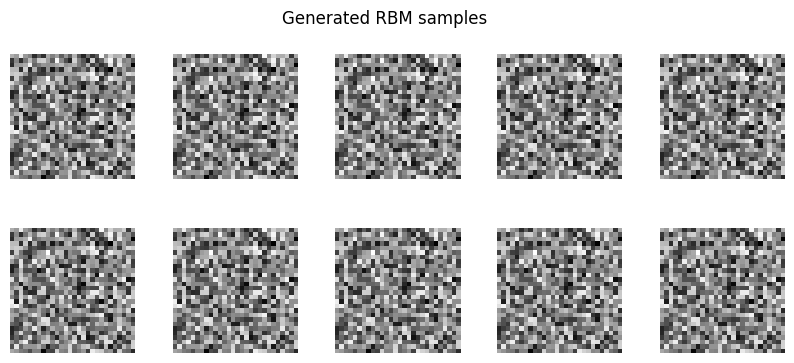

In [ ]:
visible_dim = 28 * 28
hidden_dim = 25  # 5x5 grid for plot_weights

# rbm = RBM(visible_dim, hidden_dim)

v_prob, energies, h_prob = rbm.gibbs_data_gen_TA(
    num_samples=10,
    gibbs_steps=200,
    use_thermal_annealing=True,
    initial_temperature=1.5,
)

print("generated visible probs shape:", v_prob.shape)
print("energies:", energies)
print("hidden probs shape:", h_prob.shape)

rbm.plot_generated_samples(v_prob, title="Generated RBM samples")

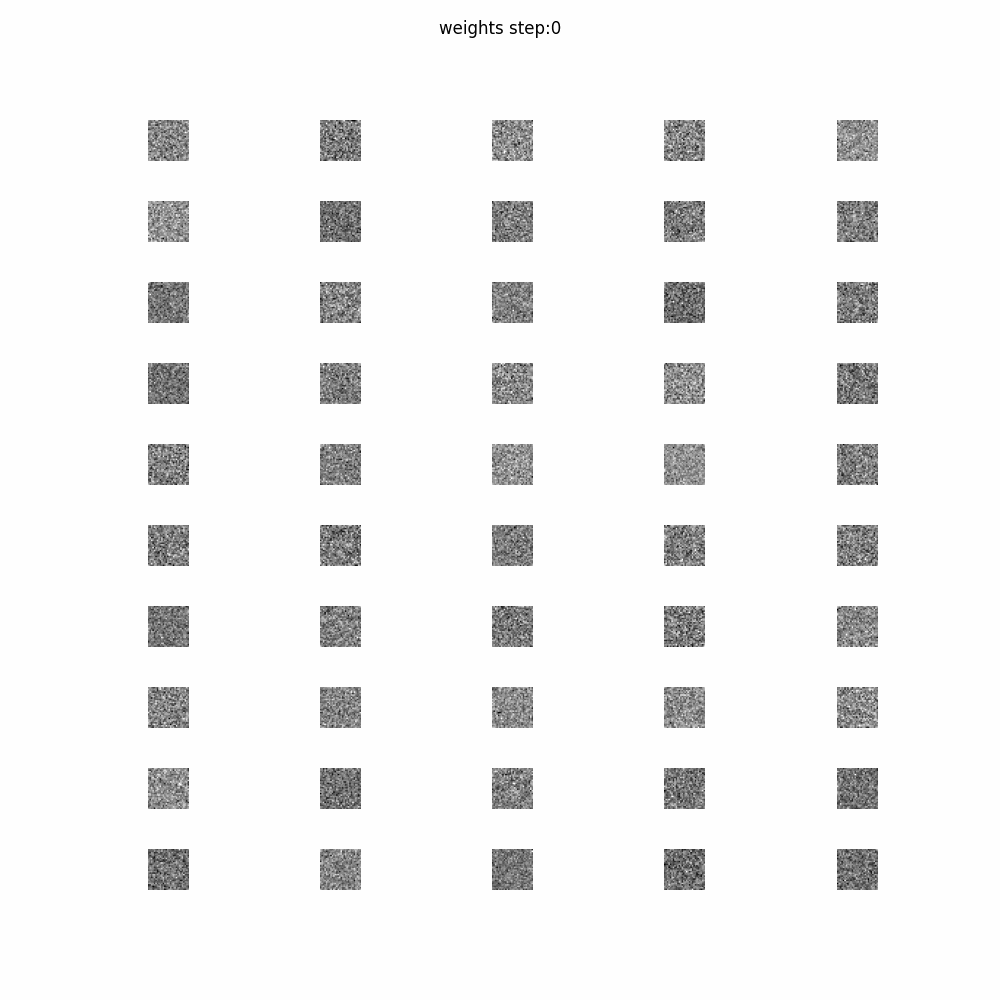

In [ ]:
### compile gif from training images
import glob
from PIL import Image
import re
import math
from pathlib import Path

file_pattern = re.compile(r'.*?(\d+).*?')
def get_order(file):
    match = file_pattern.match(Path(file).name)
    if not match:
        return math.inf
    return int(match.groups()[0])


frames = [Image.open(image) for image in sorted(glob.glob(f"./weights_saved/weights_step_*.png"), key=get_order)]
frame_one = frames[0]
frame_one.save("./weights_saved/weights.gif", format="GIF", append_images=frames,
               save_all=True, duration=500, loop=0)

# if you are using a notebook
from IPython.display import Image
Image(open('./weights_saved/weights.gif','rb').read())

In [ ]:
print(y_test.shape)

(10000,)


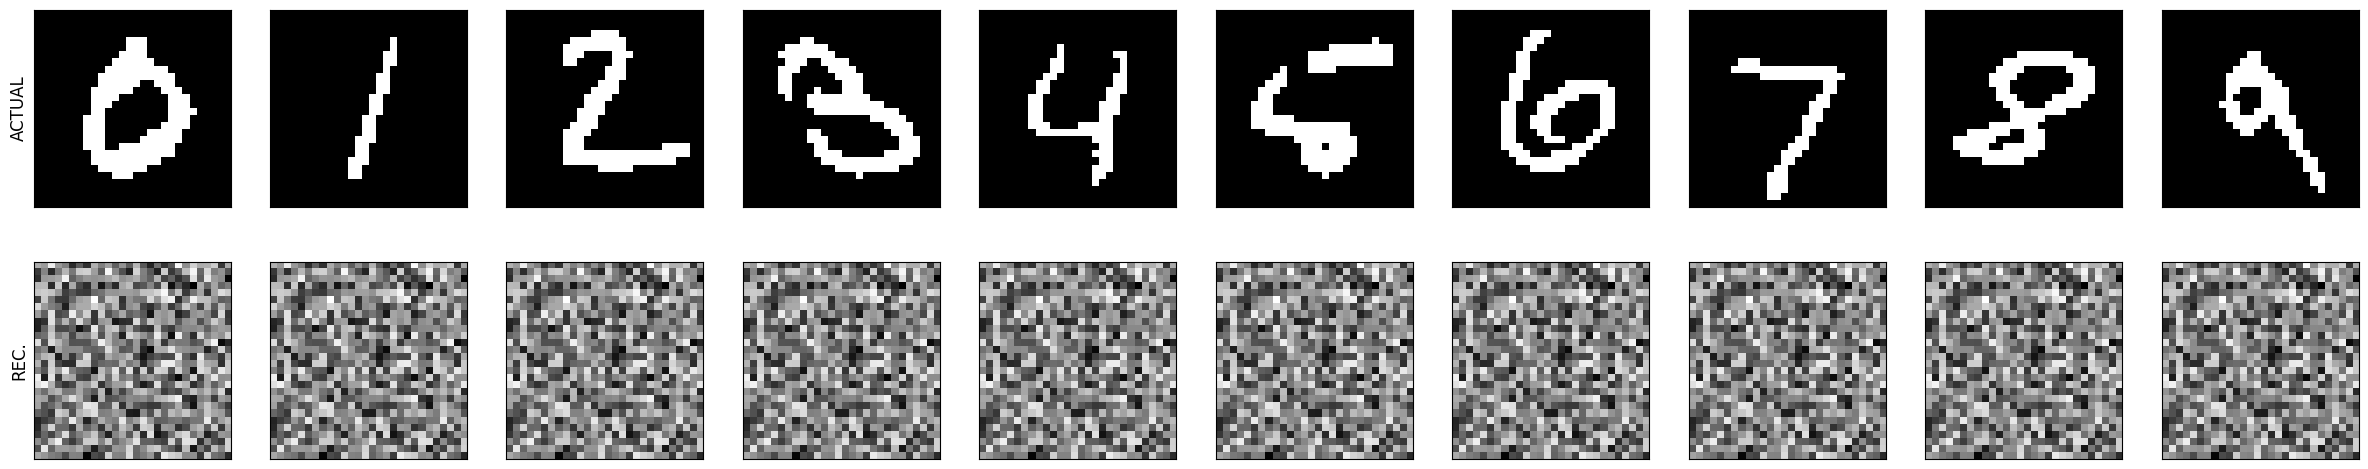

In [ ]:
# get one image of the test set for each digit
# Create a list of indices for each digit

# chose 10 images where each has a different label (1 to 10) and put the image index ([0][0]) in a list
digit_indices = [np.where(y_test == i)[0][0] for i in range(10)]
# get the indexed images from the test set in tensor form
test_set_image_tensor = X_test[digit_indices]

# 
reconstructed = rbm.reconstruct(test_set_image_tensor)

# show 10 sample images
rows = 2
columns = 10

fig, axes = plt.subplots(rows, columns,sharey = True,figsize=(30, 6))
for i in range(rows):
    for j in range(columns):
        if i==0:
          axes[i, j].imshow(test_set_image_tensor[j].reshape(28, 28), cmap='gray')
        else:
          axes[i, j].imshow(reconstructed[j].reshape(28, 28), cmap='gray')

        axes[i, j].tick_params(left = False, right = False , labelleft = False,
                labelbottom = False, bottom = False)

axes[0, 0].set_ylabel("ACTUAL", fontsize=12)
axes[1, 0].set_ylabel("REC.", fontsize=12)
plt.show()

In [ ]:
from skimage.metrics import structural_similarity as ssim
# reconstruct the whole testset
reconstructed = rbm.reconstruct(X_test)

# convert test set into float numbers to apply ssim score
X_test1 = X_test.astype(float)

ssim_score=0
for i in range(len(X_test1)):
  ssim_score +=ssim(X_test1[i], reconstructed[i], data_range=X_test1[i].max() - X_test1[i].min())

# mean overall the samples
ssim_score /= len(X_test)

print(f"SSIM score: {ssim_score}")

SSIM score: -0.00024666309747115993


fin